<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/traffic2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
!pip install catboost
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

(77299, 11)
(41778, 10)


In [4]:
train['RoadType'] = train['RoadType'].fillna(
    train['RoadType'].mode()[0]
)

test['RoadType'] = test['RoadType'].fillna(
    train['RoadType'].mode()[0]
)

train['Weather'] = train['Weather'].fillna(
    train['Weather'].mode()[0]
)

test['Weather'] = test['Weather'].fillna(
    train['Weather'].mode()[0]
)

train['Temperature'] = train['Temperature'].fillna(
    train['Temperature'].median()
)

test['Temperature'] = test['Temperature'].fillna(
    train['Temperature'].median()
)

In [5]:
train['timestamp'] = pd.to_datetime(
    train['timestamp'],
    format='%H:%M'
)

test['timestamp'] = pd.to_datetime(
    test['timestamp'],
    format='%H:%M'
)

train['hour'] = train['timestamp'].dt.hour
test['hour'] = test['timestamp'].dt.hour

In [6]:
road_map = {
    'Residential':1,
    'Street':2,
    'Highway':3
}

train['RoadType_enc'] = (
    train['RoadType']
    .map(road_map)
    .astype(int)
)

test['RoadType_enc'] = (
    test['RoadType']
    .map(road_map)
    .astype(int)
)

In [7]:
vehicle_map = {
    'Allowed':1,
    'Not Allowed':0
}

train['LargeVehicles'] = (
    train['LargeVehicles']
    .map(vehicle_map)
)

test['LargeVehicles'] = (
    test['LargeVehicles']
    .map(vehicle_map)
)

In [8]:
landmark_map = {
    'Yes':1,
    'No':0
}

train['Landmarks'] = (
    train['Landmarks']
    .map(landmark_map)
)

test['Landmarks'] = (
    test['Landmarks']
    .map(landmark_map)
)

In [9]:
train['road_lane'] = (
    train['RoadType_enc']
    *
    train['NumberofLanes']
)

test['road_lane'] = (
    test['RoadType_enc']
    *
    test['NumberofLanes']
)

In [10]:
train['road_vehicle'] = (
    train['RoadType_enc']
    *
    train['LargeVehicles']
)

test['road_vehicle'] = (
    test['RoadType_enc']
    *
    test['LargeVehicles']
)

In [11]:
geo_freq_map = train['geohash'].value_counts()

train['geo_freq'] = train['geohash'].map(
    geo_freq_map
)

test['geo_freq'] = (
    test['geohash']
    .map(geo_freq_map)
    .fillna(0)
)

In [12]:
train['geo_hour'] = (
    train['geohash']
    + "_"
    + train['hour'].astype(str)
)

test['geo_hour'] = (
    test['geohash']
    + "_"
    + test['hour'].astype(str)
)

In [13]:
train['road_hour'] = (
    train['RoadType_enc'].astype(str)
    + "_"
    + train['hour'].astype(str)
)

test['road_hour'] = (
    test['RoadType_enc'].astype(str)
    + "_"
    + test['hour'].astype(str)
)

In [14]:
train['geo_road'] = (
    train['geohash']
    + "_"
    + train['RoadType_enc'].astype(str)
)

test['geo_road'] = (
    test['geohash']
    + "_"
    + test['RoadType_enc'].astype(str)
)

In [15]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

global_mean = train['demand'].mean()

In [16]:
train['geo_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geohash'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_target_kfold'
    ] = val['geohash'].map(means)

train['geo_target_kfold'] = (
    train['geo_target_kfold']
    .fillna(global_mean)
)

In [17]:
train['geo_hour_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geo_hour'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_hour_target_kfold'
    ] = val['geo_hour'].map(means)

train['geo_hour_target_kfold'] = (
    train['geo_hour_target_kfold']
    .fillna(global_mean)
)

In [18]:
train['road_hour_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'road_hour'
    )['demand'].mean()

    train.loc[
        val_idx,
        'road_hour_target_kfold'
    ] = val['road_hour'].map(means)

train['road_hour_target_kfold'] = (
    train['road_hour_target_kfold']
    .fillna(global_mean)
)

In [19]:
train['geo_road_target_kfold'] = np.nan

for tr_idx,val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby(
        'geo_road'
    )['demand'].mean()

    train.loc[
        val_idx,
        'geo_road_target_kfold'
    ] = val['geo_road'].map(means)

train['geo_road_target_kfold'] = (
    train['geo_road_target_kfold']
    .fillna(global_mean)
)

In [20]:
geo_mean = train.groupby(
    'geohash'
)['demand'].mean()

test['geo_target_kfold'] = (
    test['geohash']
    .map(geo_mean)
    .fillna(global_mean)
)

In [21]:
geo_hour_mean = train.groupby(
    'geo_hour'
)['demand'].mean()

test['geo_hour_target_kfold'] = (
    test['geo_hour']
    .map(geo_hour_mean)
    .fillna(global_mean)
)

In [22]:
road_hour_mean = train.groupby(
    'road_hour'
)['demand'].mean()

test['road_hour_target_kfold'] = (
    test['road_hour']
    .map(road_hour_mean)
    .fillna(global_mean)
)

In [23]:
geo_road_mean = train.groupby(
    'geo_road'
)['demand'].mean()

test['geo_road_target_kfold'] = (
    test['geo_road']
    .map(geo_road_mean)
    .fillna(global_mean)
)

In [24]:
print(
    test['road_hour_target_kfold']
    .eq(global_mean)
    .mean()
)

print(
    test['geo_road_target_kfold']
    .eq(global_mean)
    .mean()
)

0.0
0.02915410024414764


In [27]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

best_features = [
    'day',
    'hour',
    'RoadType_enc',
    'geo_freq',
    'road_lane',
    'road_vehicle',
    'geo_target_kfold',
    'geo_hour_target_kfold',
    'road_hour_target_kfold',
    'geo_road_target_kfold'
]

X = train[best_features]
y = train['demand']

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        use_best_model=True
    )

    preds = model.predict(X_val)

    score = r2_score(y_val, preds)

    scores.append(score)

    print(f"Fold {fold}: {score:.6f}")

print("\nMean CV R² =", np.mean(scores))
print("Std CV R² =", np.std(scores))

Fold 1: 0.955272
Fold 2: 0.953009
Fold 3: 0.956866
Fold 4: 0.952726
Fold 5: 0.958374

Mean CV R² = 0.9552495423937583
Std CV R² = 0.0021802152602378414


In [28]:
X = train[best_features]
y = train['demand']

final_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=200
)

final_model.fit(X, y)

0:	learn: 0.0532204	total: 36.9ms	remaining: 55.4s
200:	learn: 0.9558408	total: 3.6s	remaining: 23.2s
400:	learn: 0.9593799	total: 6.62s	remaining: 18.1s
600:	learn: 0.9617557	total: 10s	remaining: 15s
800:	learn: 0.9634312	total: 13.8s	remaining: 12s
1000:	learn: 0.9647137	total: 16.8s	remaining: 8.39s
1200:	learn: 0.9657892	total: 19.7s	remaining: 4.9s
1400:	learn: 0.9666708	total: 23.1s	remaining: 1.63s
1499:	learn: 0.9670966	total: 25.2s	remaining: 0us


CatBoostRegressor(depth=8, eval_metric='R2', iterations=1500, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [29]:
X_test = test[best_features]

predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    'Index': test['Index'],
    'demand': predictions
})

submission['demand'] = submission['demand'].clip(lower=0)

submission.to_csv(
    'submission_fixed.csv',
    index=False
)

In [30]:
submission.head()
print(submission.shape)
print(submission.isnull().sum())

(41778, 2)
Index     0
demand    0
dtype: int64


In [31]:
old = pd.read_csv("submission_final.csv")
new = pd.read_csv("submission_fixed.csv")

print("OLD")
print(old['demand'].describe())

print("\nNEW")
print(new['demand'].describe())

OLD
count    41778.000000
mean         0.120978
std          0.103924
min          0.013671
25%          0.041654
50%          0.086534
75%          0.157630
max          0.598103
Name: demand, dtype: float64

NEW
count    41778.000000
mean         0.126900
std          0.158217
min          0.001257
25%          0.032372
50%          0.067775
75%          0.137638
max          0.948499
Name: demand, dtype: float64


In [32]:
diff = abs(new['demand'] - old['demand'])

print("Mean Difference:", diff.mean())
print("Max Difference:", diff.max())
print("Rows Changed:", (diff > 1e-6).sum())

Mean Difference: 0.03032630940368146
Max Difference: 0.4581368510173715
Rows Changed: 41778


In [33]:
corr = old['demand'].corr(new['demand'])

print("Correlation:", corr)

Correlation: 0.9704066763929239


In [34]:
comparison = pd.DataFrame({
    'Index': old['Index'],
    'old': old['demand'],
    'new': new['demand']
})

comparison['diff'] = abs(
    comparison['new'] - comparison['old']
)

comparison.sort_values(
    'diff',
    ascending=False
).head(20)

,Index,old,new,diff
39163,39163,0.418285,0.876422,0.458137
23438,23438,0.447343,0.892799,0.445456
21668,21668,0.447343,0.892799,0.445456
27058,27058,0.451486,0.890499,0.439013
26150,26150,0.451486,0.890499,0.439013
25251,25251,0.451486,0.890499,0.439013
34182,34182,0.458831,0.892670,0.433840
28719,28719,0.447514,0.873803,0.426289
34899,34899,0.451795,0.877936,0.426141
32277,32277,0.451795,0.877936,0.426141


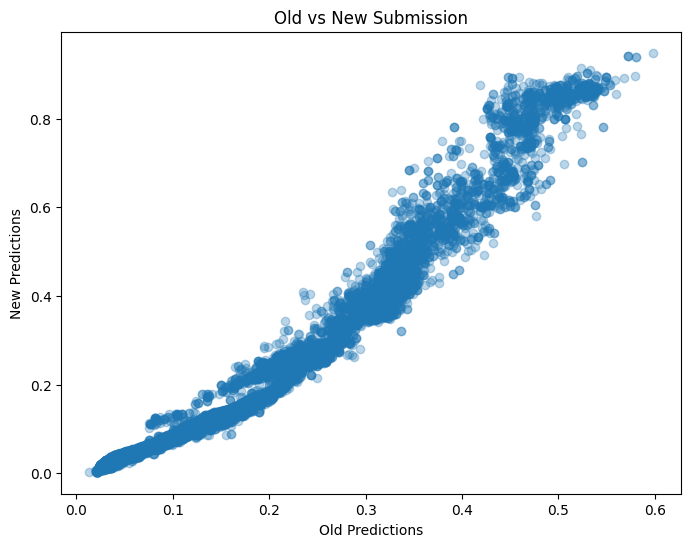

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    old['demand'],
    new['demand'],
    alpha=0.3
)

plt.xlabel("Old Predictions")
plt.ylabel("New Predictions")
plt.title("Old vs New Submission")
plt.show()

In [36]:
corr = old['demand'].corr(new['demand'])
print(corr)

0.9704066763929239


In [37]:
diff = abs(new['demand'] - old['demand'])
print(diff.mean())

0.03032630940368146


In [39]:
old = pd.read_csv("submission_final.csv")
new = pd.read_csv("submission_fixed.csv")

comparison = pd.DataFrame({
    "old": old["demand"],
    "new": new["demand"]
})

comparison["diff"] = abs(
    comparison["new"] - comparison["old"]
)

print(comparison["diff"].describe())

count    41778.000000
mean         0.030326
std          0.055102
min          0.000002
25%          0.010846
50%          0.016069
75%          0.022493
max          0.458137
Name: diff, dtype: float64
